In [2]:
# 1. 导入依赖的包
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pdb

warnings.filterwarnings('ignore')

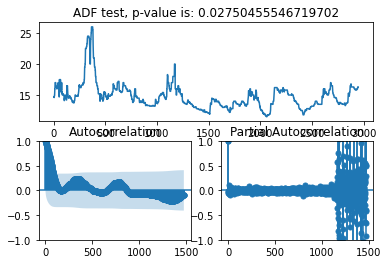

In [9]:
# 2. 准备数据
# 读取数据，并做可视化展示，以及一并绘制自相关、偏自相关图，还有平稳性检验。
def read_data():
    # file = '4_预测/ARIMA/in.xlsx'
    # df = pd.read_excel(file)
    df = pd.read_excel('/Users/bigcolour/Desktop/水产品价格预测/代码/new/4_预测/ARIMA/sarima_in.xlsx')

    ts = df.price

    return ts

def plot(ts):
    results = adfuller(ts)
    results_str = 'ADF test, p-value is: {}'.format(results[1])

    grid = plt.GridSpec(2, 2)
    ax1 = plt.subplot(grid[0, :])
    ax2 = plt.subplot(grid[1, 0])
    ax3 = plt.subplot(grid[1, 1])

    ax1.plot(ts)
    ax1.set_title(results_str)
    plot_acf(ts, lags=int(len(ts) / 2 - 1), ax=ax2)
    plot_pacf(ts, lags=int(len(ts) / 2 - 1), ax=ax3)
    plt.show()
    
ts = read_data()
plot(ts)

In [11]:
# 5. 模型验证（Auto-SARIMA，pmdarima）
# 直接使用的pmdarima自动调参（d通过ADF检验确定，D通过Canova-Hansen检验确定，(p,q)(P,Q)一样grid search）。
def version_sarima_with_pmdarima(ts):
    """
    Auto-SARIMA（pmdarima）
    """
    # 周期大小
    periods = 365

    # 数据拆分
    train, test = train_test_split(ts, train_size=0.8)

    # 模型训练
    model = pm.auto_arima(train, seasonal=True, m=periods)
    print(model.summary())

    # 拟合结果
    fitted = model.predict_in_sample()
    fitted = pd.Series(fitted, index=train.index)

    # 模型预测
    fcst = model.predict(test.shape[0])
    fcst = pd.Series(fcst, index=test.index)

    # 模型评估
    rmse = np.sqrt(mean_squared_error(test, fcst))
    print('RMSE: %.4f' % rmse)

    # 可视化
    plt.figure(figsize=(12, 4))
    ts.plot(label='Ads')
    fitted.plot(label='fitted')
    fcst.plot(label='forecast')
    plt.legend()
    plt.grid(True)
    plt.title('pmdarima-SARIMA')
    plt.show()
    
version_sarima_with_pmdarima(ts)